In [94]:
# ============================================================
# セル1-5: 前処理とグラフ構築 (一括実行)
# ============================================================
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def safe_parse_embedding(x):
    """埋め込みベクトルを柔軟にパースする"""
    if pd.isna(x) or x == "":
        return None
    
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_data(file_path):
    """データ前処理のメイン関数"""
    print("1. データ読み込み開始...")
    df = pd.read_csv(file_path)
    
    print("2. 埋め込みベクトルを結合中...")
    combined_vectors = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row['description_embedding'])
        meta = safe_parse_embedding(row['metadata_embedding'])
        
        if desc is not None and meta is not None:
            combined_vectors.append(np.concatenate([desc, meta]))
            valid_indices.append(i)
        
        if i % 10000 == 0 and i > 0:
            print(f"  {i}件処理済み...")

    if not combined_vectors:
        print("⚠️ ベクトルが生成されません。データの中身を確認してください。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    print(f"  結合成功: {len(df)} 件")

    print("3. 追加の前処理（企業名・日付）を実行中...")
    def parse_corp(x):
        try:
            return ast.literal_eval(x) if isinstance(x, str) else x
        except:
            return x
    
    df["corporation"] = df["corporation"].apply(parse_corp)
    df['year_month'] = pd.to_datetime(df['year_month'])
    df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]
    
    if len(df) > 0:
        v_dim = len(df.iloc[0]['combined_vector'])
        print(f"✓ 前処理完了: {len(df)} 件（次元数: {v_dim}）")
    else:
        print("⚠️ 日付フィルタリング後にデータが0件になりました。")
        
    return df

def build_global_graphs(df):
    """動的グラフの構築"""
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    print(f"企業数: {len(all_corporations)}, 特許数: {len(all_patents)}")
    
    # 特許特徴量の準備
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']

    global_graph_dict = {}
    year_groups = df.groupby(df['year_month'].dt.year)
    
    # 各年のリンク履歴を保存（Historical Negatives用）
    all_historical_edges = set()
    
    for year, group in year_groups:
        edges = []
        active_nodes = set()
        
        for _, row in group.iterrows():
            p_idx = patent_to_idx[row['patent_number']]
            active_nodes.add(p_idx)
            for corp in row['corporation']:
                c_idx = corp_to_idx[corp]
                edges.append([c_idx, p_idx])
                active_nodes.add(c_idx)
                all_historical_edges.add((c_idx, p_idx))
        
        if not edges:
            continue
        
        # 特徴行列の初期化
        input_dim = len(next(iter(patent_features.values())))
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features:
                x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[list(active_nodes)] = True
        
        global_graph_dict[year] = Data(
            x=x, 
            edge_index=edge_index, 
            active_mask=active_mask, 
            year=year,
            num_nodes=total_nodes
        )
        
    return global_graph_dict, all_corporations, all_patents, patent_to_idx, total_nodes, corp_to_idx, all_historical_edges

# データ読み込みと前処理 (前の定義を流用)
df = preprocess_data('../dataset/topic_info3.csv')
graphs, corps, patents, p_map, total_n, c_map, historical_edges = build_global_graphs(df)
num_corps = len(corps)
input_dim = graphs[list(graphs.keys())[0]].x.shape[1]

1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
  10000件処理済み...
  20000件処理済み...
  30000件処理済み...
  40000件処理済み...
  結合成功: 42789 件
3. 追加の前処理（企業名・日付）を実行中...
✓ 前処理完了: 19389 件（次元数: 1088）
企業数: 2450, 特許数: 19384


In [95]:
df

,patent_number,patent_name,date,corporation,ipc,lead_ipc,fi,fterm,keyword,description,year,month,description_embedding,metadata_embedding,lead_inventor,inventors,year_month,topic_id,sim_score,combined_vector
23373,特開2011-147544,患者搬送装置,201001,[株式会社テクネット],[],A61G 5/00 (2006.01),[],[],"['簡単', '運搬']",場所を取らない簡単な構造により、感染患者等を隔離した状態で搬送することができる,2010,1,"[0.022907990962266922, 0.017237883061170578, -...",[ 0.34335172 -0.19837284 0.26558578 0.187770...,山口 一,"山口 一,伊澤 康一,梶間 智明,田中 勲,辻 裕次,三浦 靖弘,釜石 裕光",2010-01-01,1,0.898545,"[0.022907991, 0.017237883, -0.01705683, -0.029..."
23374,特開2011-147869,二酸化炭素の地中貯留施設およびその施工方法,201001,[清水建設株式会社],"['B01J 19/00 (2006.01)', 'E02D 29/045 (...",B01J 19/00 (2006.01),"['B01J 19/00 A', 'E02D 29/04 A', 'E0...","['2D047AB02', '4G075AA04', '2D147AB02']","['二酸化炭素', '貯留', '有効適切', '施工方法']",二酸化炭素の非構造型貯留層への貯留を可能とする有効適切な地中貯留施設とその施工方法を提供する,2010,1,"[0.030319971963763237, -0.015537390485405922, ...",[ 0.25184226 -0.23450097 0.24443543 0.197358...,米山 一幸,米山 一幸,2010-01-01,8,0.913877,"[0.030319972, -0.0155373905, -0.01071435, -0.0..."
23375,特開2011-149178,導枠及び海底探査方法,201001,"[株式会社熊谷組, 東光電気工事株式会社, 株式会社森長組]","['E02D 13/04 (2006.01)', 'E02D 27/52 (...",E02D 13/04 (2006.01),['E02D 13/04'],"['2D046DA62', '2D050AA06', '2D050CB14', '2D050...","['短期化', '施工コスト', '低減化']",工期の短縮化や施工コストの低減化を図る,2010,1,"[0.006442359182983637, 0.020957233384251595, -...",[ 3.8005432e-01 -2.2637601e-01 1.2717944e-01 ...,牛腸 明,"牛腸 明,矢嶋 英明,竹村 雅彦,岡野 雅史,島田 喜章,谷口 岩男",2010-01-01,5,0.926848,"[0.006442359, 0.020957233, -0.01782004, -0.052..."
23376,特開2011-149181,モノパイル式基礎施工方法,201001,"[株式会社熊谷組, 東光電気工事株式会社]","['E02D 7/00 (2006.01)', 'E02D 27/32 (...",E02D 7/00 (2006.01),"['E02D 7/00 A', 'E02D 27/32 A', 'E0...","['2D046CA08', '2D046DA05', '2D050AA01', '2D050...","['短期化', '施工コスト', '低減化']",工期の短縮化や施工コストの低減化を図る,2010,1,"[0.006442359182983637, 0.020957233384251595, -...",[ 0.37698632 -0.23764831 0.13028508 0.141271...,牛腸 明,"牛腸 明,矢嶋 英明,竹村 雅彦,岡野 雅史",2010-01-01,5,0.926848,"[0.006442359, 0.020957233, -0.01782004, -0.052..."
23377,特開2011-149182,杭基礎の施工方法,201001,[株式会社熊谷組],"['E02D 27/12 (2006.01)', 'E02D 27/16 (...",E02D 27/12 (2006.01),"['E02D 27/12 Z', 'E02D 27/16']","['2D046CA01', '2D046CA08']","['グラウト', '短期化', '施工コスト', '低減化']",グラウトの漏出を確実に防止すると共に、工期の短縮化や施工コストの低減化を図る,2010,1,"[-0.005412539932876825, 0.014347787015140057, ...",[ 0.3640074 -0.2338481 0.13964486 0.139466...,牛腸 明,"牛腸 明,矢嶋 英明",2010-01-01,3,0.933085,"[-0.00541254, 0.014347787, -0.023784904, -0.04..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42757,WO2021/140940,農産物栽培支援装置、農産物栽培システム、および農産物栽培支援方法,202012,"[株式会社大林組, 原嶋 寛, 住吉 栄作, 緒方 浩基]","['G06Q 50/02 (2012.01)', 'A01G 7/00 (...",G06Q 50/02 (2012.01),[],[],['測定値'],農産物栽培支援装置は、農業ハウスの栽培空間の複数の光合成要素について測定値を取得する,2020,12,"[0.0313706174492836, 0.01707536354660988, -0.0...",[ 0.19453254 -0.30019754 0.10449462 0.146774...,原嶋 寛,"原嶋 寛,住吉 栄作,緒方 浩基",2020-12-01,2,0.881575,"[0.031370617, 0.017075364, -0.03717448, -0.047..."
42758,WO2021/140941,収穫予測装置、収穫予測方法,202012,"[株式会社大林組, 中村 奈美]","['G06Q 50/02 (2012.01)', 'A01G 7/00 (...",G06Q 50/02 (2012.01),[],[],[],収穫予測装置は撮像部に接続された制御部を備える,2020,12,"[0.01752316951751709, 0.00962613895535469, -0....",[ 0.24668053 -0.2343066 0.18544462 0.098285...,中村 奈美,中村 奈美,2020-12-01,1,0.883478,"[0.01752317, 0.009626139, -0.019505411, -0.046..."
42759,特開2021-047923,情報処理システム及び情報処理システム用プログラム,202012,[高砂熱学工業株式会社],['G06Q 50/08 (2012.01)'],G06Q 50/08 (2012.01),['G06Q 50/08'],['5L049CC07'],"['建築現場', 'メンテナンス']",建築現場における管理を容易にする,2020,12,"[0.016471637412905693, 0.013141311705112457, -...",[ 0.27461112 -0.21962798 0.1781581 0.259755...,佐藤 彰洋,"佐藤 彰洋,鈴木 崇浩",2020-12-01,1,0.919058,"[0.016471637, 0.013141312, -0.039926685, -0.04..."
42760,特開2021-105333,天井点検口,202012,[前田建設工業株式会社],['E04F 19/08 (2006.01)'],E04F 19/08 (2006.01),[],[],"['軽微', '保守作業']",軽微な保守作業の実施時における操作性を向上させることができる天井点検口を提供する,2020,12,"[0.009724111296236515, 0.008886716328561306, -...",[ 0.26950538 -0.28889984 0.13830602 0.275950...,佐竹 晃,佐竹 晃,2020-12-01,5,0.920917,"[0.009724111, 0.008886716, -0

In [96]:
input_dim

1088

In [97]:
num_corps

2450

In [98]:
# ============================================================
# セル9: モデルクラスの定義（エンコーダ）
# ============================================================
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

In [99]:
# ============================================================
# セル11: 統合VGAEモデルの定義
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=64, predictor_type='ode', sequence_length=3, augment_dim=4):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.predictor_type = predictor_type
        self.latent_dim = latent_dim
        self.input_dim = input_dim
        self.sequence_length = sequence_length

        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)

        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)

        if predictor_type == 'ode':
            self.temporal_predictor = NeuralODEPredictor(latent_dim, hidden_dim)
        elif predictor_type == 'gradient_ode': 
            self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)
        elif predictor_type == 'anode':
            self.temporal_predictor = AugmentedNeuralODEPredictor(latent_dim, augment_dim, hidden_dim=hidden_dim)
        elif predictor_type == 'mlp':
            self.temporal_predictor = MLPPredictor(sequence_length, latent_dim, hidden_dim)
        elif predictor_type == 'rnn':
            self.temporal_predictor = RNNPredictor(latent_dim, hidden_dim)
        elif predictor_type == 'lstm':
            self.temporal_predictor = LSTMPredictor(latent_dim, hidden_dim)
        else:
            raise ValueError(f"サポートされていない predictor_type: {predictor_type}")

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        self.generative_decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, input_dim)
        )

    def get_node_features(self, x, node_indices=None):
        if node_indices is not None:
            features = x.clone()
            corp_mask = node_indices < self.num_corps
            if corp_mask.any():
                corp_indices = node_indices[corp_mask]
                features[corp_mask] = self.corp_embeddings(corp_indices)
            return features
        return x

    def encode(self, x, edge_index, node_indices=None):
        edge_index = edge_index.long()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def decode(self, z, edge_index):
        edge_index = edge_index.long()
        z_i = z[edge_index[0]]
        z_j = z[edge_index[1]]
        combined = torch.cat([z_i, z_j], dim=-1)
        return torch.sigmoid(self.link_predictor(combined)).squeeze()

    def predict_future(self, z_history_list):
        try:
            if self.predictor_type in ['ode', 'anode']:
                z_current = z_history_list[-1]
                return self.temporal_predictor(z_current)
            elif self.predictor_type in ['mlp', 'rnn', 'lstm']:
                return self.temporal_predictor(z_history_list)
            else:
                raise ValueError(f"予期しない predictor_type: {self.predictor_type}")
        except Exception as e:
            print(f"時系列予測エラー ({self.predictor_type}): {e}")
            return z_history_list[-1]

In [100]:
# ============================================================
# セル10-11: 勾配ベースの Neural ODE モデル
# ============================================================

class PotentialNet(nn.Module):
    """座標 z における『企業の集積度（ポテンシャル）』を計算する"""
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Softplus(), # 滑らかな等高線のためにSoftplusを使用
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, 1) # 出力はポテンシャルの高さ(スカラー)
        )

    def forward(self, z):
        return self.net(z)

class GradientODEFunc(nn.Module):
    """ポテンシャルの勾配（坂道の向き）を速度ベクトルとして返す"""
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            # 勾配（微分の方向）を計算：これが速度ベクトルになる
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        return torch.tanh(self.scale) * grad_z

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        # 勾配に従って位置 z を更新（坂道を登る）
        z_future = odeint(self.ode_func, z_current, t_span, method='dopri5')[-1]
        return z_future

# UnifiedVGAEに組み込み
class PotentialAwareVGAE(UnifiedVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=16):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim, predictor_type='ode')
        # 予測器を勾配ベースに差し替え
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

    def predict_future(self, z_history_list):
        return self.temporal_predictor(z_history_list[-1])

In [101]:
# ============================================================
# セル13: ポテンシャル損失を含む計算
# ============================================================

def compute_potential_loss(model, data_t, data_t1, num_corps, z_history, historical_edges, potential_weight=2.0):
    # 1. 基本的な VGAE 損失 (リンク予測)
    # ここでは簡略化のため base_loss として統合
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # --- ポテンシャルのターゲット（企業参入数）の作成 ---
    # 特許ごとのエッジ数（参入企業数）をカウント
    edge_index = data_t.edge_index
    patents_in_edges = edge_index[1]
    unique_p, counts = torch.unique(patents_in_edges, return_counts=True)
    
    # dfからsim_scoreを取得し，特許ノードに対応させる
    sim_scores = torch.zeros(model.num_nodes, 1, device=device)
    for idx, row in df.iterrows():
        p_num = row['patent_number']
        if p_num in p_map:
            sim_scores[p_map[p_num]] = row['sim_score']

    # 参入数(counts)とsim_scoreの石をポテンシャルのターゲットにする
    target_phi[unique_p] = (counts.view(-1, 1).float() * sim_scores[unique_p])
    target_phi = torch.log1p(target_phi) # スケール安定化
    if target_phi.max() > 0: target_phi /= target_phi.max()

    # 2. ポテンシャル予測損失 (MSE)
    pred_phi = model.temporal_predictor.potential_net(mu_t)
    patent_mask = (torch.arange(model.num_nodes, device=device) >= num_corps) & data_t.active_mask
    potential_loss = F.mse_loss(pred_phi[patent_mask], target_phi[patent_mask])

    # 3. 未来予測損失 (軌跡の整合性)
    z_t1_pred = model.predict_future(z_history)
    with torch.no_grad():
        _, mu_t1_real, _ = model.encode(data_t1.x, data_t1.edge_index)
    traj_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_real[data_t1.active_mask])

    total_loss = potential_loss * potential_weight + traj_loss
    return total_loss, {'total': total_loss.item(), 'phi_loss': potential_loss.item()}

In [102]:
class NeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.ode_func = ODEFunc(latent_dim, hidden_dim)

    def forward(self, z_current, delta_t=0.5):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        try:
            z_future = odeint(
                self.ode_func, z_current, t_span,
                method='dopri5', rtol=1e-4, atol=1e-4,
                options={'max_num_steps': 1000}
            )[-1]
            
            if torch.isnan(z_future).any() or torch.isinf(z_future).any():
                print("Warning: ODE solution contains NaN/Inf")
                return z_current
            return z_future
        except Exception as e:
            print(f"ODE予測エラー: {e}")
            return z_current

In [103]:
class ODEFunc(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim + 1, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim)
        )
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        t_vec = t.expand(z.size(0), 1)
        z_t = torch.cat([z, t_vec], dim=1)
        dz = self.net(z_t)
        return torch.tanh(self.scale) * dz

In [104]:
# ============================================================
# セル18: ポテンシャル場の学習
# ============================================================

model = PotentialAwareVGAE(total_n, num_corps, input_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
years = sorted(graphs.keys())

print("Innovation Potential Field の学習を開始します...")
for epoch in range(31):
    model.train()
    epoch_phi_loss = []
    
    for i in range(len(years)-1):
        data_t = graphs[years[i]].to(device)
        data_t1 = graphs[years[i+1]].to(device)
        
        # 簡易的な履歴作成
        z_history = []
        for j in range(max(0, i-2), i+1):
            with torch.no_grad():
                d = graphs[years[j]].to(device)
                _, mu, _ = model.encode(d.x, d.edge_index)
                z_history.append(mu)
        
        optimizer.zero_grad()
        loss, loss_dict = compute_potential_loss(model, data_t, data_t1, num_corps, z_history, historical_edges)
        loss.backward()
        optimizer.step()
        epoch_phi_loss.append(loss_dict['phi_loss'])
        
    if epoch % 10 == 0:
        print(f"Epoch {epoch:02d} | Avg Potential Loss: {np.mean(epoch_phi_loss):.4f}")

Innovation Potential Field の学習を開始します...


UnboundLocalError: local variable 'target_phi' referenced before assignment

In [105]:
# ============================================================
# 元のコードの続き：遷移可能なポテンシャル場
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchdiffeq import odeint

class TransitionPotentialNet(nn.Module):
    """ポテンシャル場間の遷移を学習するモデル"""
    def __init__(self, latent_dim, hidden_dim, num_potentials=5):
        super().__init__()
        self.num_potentials = num_potentials
        self.latent_dim = latent_dim
        
        # 各ポテンシャル場の中心点（学習可能）
        self.centroids = nn.Parameter(torch.randn(num_potentials, latent_dim) * 0.5)
        
        # 各ポテンシャルの強さ
        self.strengths = nn.Parameter(torch.ones(num_potentials))
        
        # 各ポテンシャルの影響範囲
        self.scales = nn.Parameter(torch.ones(num_potentials))
        
        # 遷移行列（i番目のポテンシャル → j番目のポテンシャル）
        self.transition_logits = nn.Parameter(torch.randn(num_potentials, num_potentials) * 0.1)
        
        # 遷移の「容易さ」を学習するネットワーク
        self.transition_gate = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_potentials)  # 各ポテンシャルへの遷移確率
        )

    def get_current_potential_assignment(self, z):
        """各ノードが現在どのポテンシャルに属しているか判定"""
        z_expanded = z.unsqueeze(1)  # [batch, 1, dim]
        c_expanded = self.centroids.unsqueeze(0)  # [1, K, dim]
        
        # 各中心点からの距離
        distances = torch.norm(z_expanded - c_expanded, dim=-1)  # [batch, K]
        
        # 最も近いポテンシャルに所属
        current_assignment = distances.argmin(dim=-1)  # [batch]
        
        return current_assignment, distances

    def forward(self, z):
        """
        出力:
        - total_phi: 総ポテンシャル
        - individual_phis: 各ポテンシャルの値 [batch, K]
        - current_assignment: 現在の所属ポテンシャル [batch]
        - transition_probs: 遷移確率 [batch, K]
        """
        batch_size = z.size(0)
        current_assignment, distances = self.get_current_potential_assignment(z)
        
        # ガウシアンポテンシャル計算
        scales = F.softplus(self.scales)
        strengths = F.softplus(self.strengths)
        
        individual_phis = strengths * torch.exp(-distances**2 / (2 * scales**2))
        
        # 遷移確率の計算（現在の位置zから各ポテンシャルへ）
        transition_probs = F.softmax(self.transition_gate(z), dim=-1)  # [batch, K]
        
        # 遷移行列を考慮した総ポテンシャル
        # 現在いるポテンシャルiから、遷移先jへの重み付け
        transition_matrix = F.softmax(self.transition_logits, dim=-1)  # [K, K]
        
        # 各ノードの現在位置から見た有効ポテンシャル
        current_transitions = transition_matrix[current_assignment]  # [batch, K]
        weighted_phis = (individual_phis * current_transitions * transition_probs).sum(dim=-1, keepdim=True)
        
        return weighted_phis, individual_phis, current_assignment, transition_probs


class TransitionODEFunc(nn.Module):
    """遷移を考慮した勾配計算"""
    def __init__(self, transition_potential_net):
        super().__init__()
        self.potential_net = transition_potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        """
        現在のポテンシャルから「遷移しやすい」ポテンシャルへの勾配を強調
        """
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            
            # 基本的な勾配計算
            weighted_phi, individual_phis, current_assign, trans_probs = self.potential_net(z_in)
            
            # 総ポテンシャルの勾配
            grad_z = torch.autograd.grad(weighted_phi.sum(), z_in, create_graph=True)[0]
            
            # 遷移先への方向ベクトルを追加
            centroids = self.potential_net.centroids
            current_centers = centroids[current_assign]  # [batch, dim]
            
            # 遷移先の重み付き中心を計算
            target_centers = (trans_probs.unsqueeze(-1) * centroids.unsqueeze(0)).sum(dim=1)
            
            # 遷移方向のベクトル
            transition_direction = target_centers - z_in
            
            # 勾配と遷移方向を組み合わせ
            combined_direction = grad_z + 0.5 * transition_direction
            
        return torch.tanh(self.scale) * combined_direction


class TransitionPotentialVGAE(nn.Module):
    """元のUnifiedVGAEを拡張（必要な部分のみ上書き）"""
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=64, num_potentials=5):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        self.input_dim = input_dim
        
        # 元のコードのコンポーネント（エンコーダなど）
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        from __main__ import SharedVGAEEncoder  # 元のコードから流用
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        
        # 遷移可能なポテンシャル場に置き換え
        self.potential_net = TransitionPotentialNet(latent_dim, hidden_dim, num_potentials)
        self.ode_func = TransitionODEFunc(self.potential_net)
        
        # リンク予測器と生成デコーダ（元のコードと同じ）
        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        self.generative_decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, input_dim)
        )

    def get_node_features(self, x, node_indices=None):
        if node_indices is not None:
            features = x.clone()
            corp_mask = node_indices < self.num_corps
            if corp_mask.any():
                corp_indices = node_indices[corp_mask]
                features[corp_mask] = self.corp_embeddings(corp_indices)
            return features
        return x

    def encode(self, x, edge_index, node_indices=None):
        edge_index = edge_index.long()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def decode(self, z, edge_index):
        edge_index = edge_index.long()
        z_i = z[edge_index[0]]
        z_j = z[edge_index[1]]
        combined = torch.cat([z_i, z_j], dim=-1)
        return torch.sigmoid(self.link_predictor(combined)).squeeze()

    def predict_future(self, z_current, delta_t=1.0):
        """ODEで未来予測（遷移を考慮）"""
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        try:
            z_future = odeint(self.ode_func, z_current, t_span, method='dopri5')[-1]
            
            if torch.isnan(z_future).any() or torch.isinf(z_future).any():
                print("Warning: ODE solution contains NaN/Inf")
                return z_current
            return z_future
        except Exception as e:
            print(f"ODE予測エラー: {e}")
            return z_current
    
    def analyze_transitions(self, z):
        """遷移パターンの分析用メソッド"""
        with torch.no_grad():
            _, _, current_assign, trans_probs = self.potential_net(z)
            transition_matrix = F.softmax(self.potential_net.transition_logits, dim=-1)
            
            return {
                'current_potential': current_assign,
                'transition_probs': trans_probs,
                'global_transition_matrix': transition_matrix,
                'centroids': self.potential_net.centroids
            }


# ============================================================
# 損失関数の修正版（遷移の整合性を追加）
# ============================================================
def compute_transition_loss(model, data_t, data_t1, num_corps, z_history, 
                           historical_edges, potential_weight=2.0, 
                           transition_weight=1.0):
    """遷移を考慮した損失関数"""
    
    # 現在時刻のエンコード
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # 未来時刻のエンコード
    with torch.no_grad():
        z_t1_real, mu_t1_real, _ = model.encode(data_t1.x, data_t1.edge_index)
    
    # 1. 基本的なポテンシャル損失
    edge_index = data_t.edge_index
    patents_in_edges = edge_index[1]
    unique_p, counts = torch.unique(patents_in_edges, return_counts=True)
    
    target_phi = torch.zeros(model.num_nodes, 1, device=device)
    target_phi[unique_p] = counts.view(-1, 1).float()
    target_phi = torch.log1p(target_phi)
    if target_phi.max() > 0: 
        target_phi /= target_phi.max()
    
    pred_phi, _, _, _ = model.potential_net(mu_t)
    patent_mask = (torch.arange(model.num_nodes, device=device) >= num_corps) & data_t.active_mask
    potential_loss = F.mse_loss(pred_phi[patent_mask], target_phi[patent_mask])
    
    # 2. 軌跡予測損失
    z_t1_pred = model.predict_future(z_history[-1] if isinstance(z_history, list) else z_history)
    traj_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_real[data_t1.active_mask])
    
    # 3. 遷移整合性損失（新規）
    # 現在と未来でポテンシャル所属がどう変化したか
    _, _, assign_t, trans_probs_t = model.potential_net(mu_t)
    _, _, assign_t1, _ = model.potential_net(mu_t1_real)
    
    # 実際の遷移（t → t+1で所属が変わったノード）
    actual_transitions = (assign_t != assign_t1).float()
    
    # 予測した遷移確率（自分以外のポテンシャルへの遷移確率の合計）
    predicted_transition_prob = 1.0 - trans_probs_t.gather(1, assign_t.unsqueeze(1)).squeeze()
    
    # 遷移を予測できていたかの損失
    transition_loss = F.binary_cross_entropy(
        predicted_transition_prob[data_t.active_mask], 
        actual_transitions[data_t.active_mask]
    )
    
    # 総損失
    total_loss = (potential_loss * potential_weight + 
                  traj_loss + 
                  transition_loss * transition_weight)
    
    return total_loss, {
        'total': total_loss.item(),
        'phi_loss': potential_loss.item(),
        'traj_loss': traj_loss.item(),
        'transition_loss': transition_loss.item()
    }


# ============================================================
# 学習ループの修正版
# ============================================================
print("\n" + "="*60)
print("遷移可能なポテンシャル場の学習を開始")
print("="*60)

model = TransitionPotentialVGAE(
    total_n, num_corps, input_dim, 
    hidden_dim=256, latent_dim=64, num_potentials=5
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
years = sorted(graphs.keys())

for epoch in range(31):
    model.train()
    epoch_losses = {'phi': [], 'traj': [], 'transition': []}
    
    for i in range(len(years)-1):
        data_t = graphs[years[i]].to(device)
        data_t1 = graphs[years[i+1]].to(device)
        
        # 履歴の構築
        z_history = []
        for j in range(max(0, i-2), i+1):
            with torch.no_grad():
                d = graphs[years[j]].to(device)
                _, mu, _ = model.encode(d.x, d.edge_index)
                z_history.append(mu)
        
        optimizer.zero_grad()
        loss, loss_dict = compute_transition_loss(
            model, data_t, data_t1, num_corps, 
            z_history, historical_edges,
            potential_weight=2.0,
            transition_weight=1.0
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_losses['phi'].append(loss_dict['phi_loss'])
        epoch_losses['traj'].append(loss_dict['traj_loss'])
        epoch_losses['transition'].append(loss_dict['transition_loss'])
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:02d} | "
              f"Phi: {np.mean(epoch_losses['phi']):.4f} | "
              f"Traj: {np.mean(epoch_losses['traj']):.4f} | "
              f"Trans: {np.mean(epoch_losses['transition']):.4f}")

print("\n学習完了！")


# ============================================================
# 遷移パターンの可視化
# ============================================================
print("\n" + "="*60)
print("遷移行列の分析")
print("="*60)

model.eval()
with torch.no_grad():
    # 最終年のデータで分析
    final_data = graphs[years[-1]].to(device)
    z_final, _, _ = model.encode(final_data.x, final_data.edge_index)
    
    analysis = model.analyze_transitions(z_final)
    
    print("\n【グローバル遷移行列】（i→jへの遷移確率）")
    trans_matrix = analysis['global_transition_matrix'].cpu().numpy()
    print("      ", "  ".join([f"P{j}" for j in range(trans_matrix.shape[1])]))
    for i, row in enumerate(trans_matrix):
        print(f"P{i} →  ", "  ".join([f"{v:.2f}" for v in row]))
    
    print("\n【中心点の座標】（最初の3次元のみ表示）")
    centroids = analysis['centroids'].cpu().numpy()
    for i, c in enumerate(centroids):
        print(f"Potential {i}: [{c[0]:.3f}, {c[1]:.3f}, {c[2]:.3f}]")
    
    # アクティブなノードの遷移統計
    active_mask = final_data.active_mask
    current_pot = analysis['current_potential'][active_mask]
    trans_probs = analysis['transition_probs'][active_mask]
    
    print("\n【アクティブノードの所属分布】")
    for i in range(trans_matrix.shape[0]):
        count = (current_pot == i).sum().item()
        print(f"Potential {i}: {count} ノード")


遷移可能なポテンシャル場の学習を開始
Epoch 00 | Phi: 0.0993 | Traj: 3.1005 | Trans: 0.5467
Epoch 10 | Phi: 0.0993 | Traj: 8.5980 | Trans: 0.1875
Epoch 20 | Phi: 0.0993 | Traj: 5.9728 | Trans: 0.2193
Epoch 30 | Phi: 0.0993 | Traj: 3.7276 | Trans: 0.3784

学習完了！

遷移行列の分析

【グローバル遷移行列】（i→jへの遷移確率）
       P0  P1  P2  P3  P4
P0 →   0.24  0.27  0.17  0.18  0.13
P1 →   0.23  0.25  0.20  0.17  0.16
P2 →   0.19  0.19  0.20  0.20  0.23
P3 →   0.22  0.18  0.19  0.21  0.19
P4 →   0.19  0.19  0.24  0.20  0.19

【中心点の座標】（最初の3次元のみ表示）
Potential 0: [-0.546, 0.909, 0.030]
Potential 1: [-0.565, 0.510, 0.257]
Potential 2: [0.043, 0.167, -0.193]
Potential 3: [-0.724, 0.403, 0.686]
Potential 4: [-0.018, 0.582, -0.511]

【アクティブノードの所属分布】
Potential 0: 156 ノード
Potential 1: 254 ノード
Potential 2: 0 ノード
Potential 3: 0 ノード
Potential 4: 228 ノード


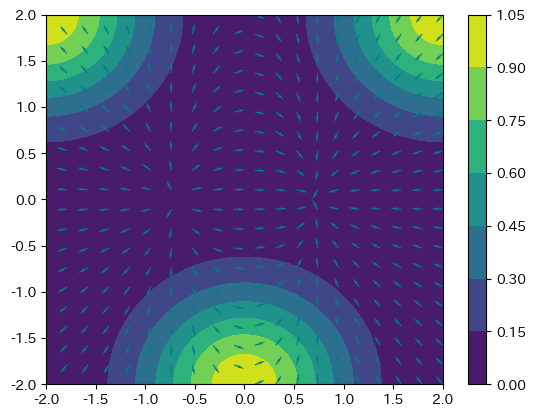

In [75]:
# Source - https://stackoverflow.com/a
# Posted by user812786
# Retrieved 2025-12-27, License - CC BY-SA 3.0

from matplotlib.pyplot import cm
import numpy as np
import matplotlib.pyplot as plt

# Contour Plot
X, Y = np.mgrid[-2:2:100j, -2:2:100j]
Z = (
    np.exp(-((X-2)**2 + (Y-2)**2)) +
    np.exp(-((X+2)**2 + (Y-2)**2)) +
    np.exp(-((X)**2   + (Y+2)**2))
)
cp = plt.contourf(X, Y, Z)
cb = plt.colorbar(cp)

# Vector Field
Y, X = np.mgrid[-2:2:20j, -2:2:20j]
U =(1 - 2*(X**2))*np.exp(-((X**2)+(Y**2)))
V = -2*X*Y*np.exp(-((X**2)+(Y**2)))
speed = np.sqrt(U**2 + V**2)
UN = U/speed
VN = V/speed
quiv = plt.quiver(X, Y, UN, VN,  # assign to var
           color='Teal', 
           headlength=7)

plt.show()


In [129]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def visualize_contour_and_quiver(model, data, num_corps):
    model.eval()
    device = next(model.parameters()).device
    
    with torch.no_grad():
        out = model.encode(data.x.to(device), data.edge_index.to(device))
        z = out[0] if isinstance(out, tuple) else out
        z_np = z.cpu().numpy()

    # 1. グリッドの設定（等高線用は細かく、ベクトル用は粗く）
    pad = 2.0
    x_min, x_max = z_np[:, 0].min() - pad, z_np[:, 0].max() + pad
    y_min, y_max = z_np[:, 1].min() - pad, z_np[:, 1].max() + pad
    
    # 等高線用の細かいグリッド (100x100)
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)
    grid_points.requires_grad_(True)
    
    phi = model.potential_net(grid_points)
    grad = torch.autograd.grad(phi.sum(), grid_points)[0]
    
    phi_plot = phi.detach().cpu().numpy().reshape(xx.shape)
    
    # 2. ベクトル（矢印）用のデータを間引く (例: 100 -> 25)
    # これを行わないと矢印が密集しすぎて見えなくなります
    skip = 4 
    xx_q = xx[::skip, ::skip]
    yy_q = yy[::skip, ::skip]
    
    grad_all = grad.detach().cpu().numpy()
    uu = grad_all[:, 0].reshape(xx.shape)[::skip, ::skip]
    vv = grad_all[:, 1].reshape(xx.shape)[::skip, ::skip]

    # プロット設定
    plt.figure(figsize=(12, 9), facecolor='black')
    ax = plt.gca()
    ax.set_facecolor('black')

    # A. 等高線（ポテンシャルの山）
    cf = plt.contourf(xx, yy, phi_plot, levels=30, cmap='magma', alpha=0.8)
    plt.colorbar(cf, label='Innovation Potential')

    # B. ベクトル場（Quiver Plot）
    # pivot='mid' で点の上に矢印の中心が来るようにし、
    # color=(1, 1, 1, 0.5) で半透明の白に設定
    plt.quiver(xx_q, yy_q, uu, vv, color=(1, 1, 1, 0.6), 
               angles='xy', scale_units='xy', scale=5.0, # scaleを調整して矢印の長さを調整
               width=0.003, headwidth=3, headlength=4, pivot='mid')

    # C. ノード（企業：水色、特許：白）
    plt.scatter(z_np[num_corps:, 0], z_np[num_corps:, 1], c='white', s=2, alpha=0.2, label='Patents')
    plt.scatter(z_np[:num_corps, 0], z_np[:num_corps, 1], c='cyan', s=35, 
                edgecolors='white', linewidth=0.5, label='Companies')

    plt.title("Technology Potential Contours & Migration Vectors", color='white', fontsize=15)
    plt.legend(facecolor='black', labelcolor='white', loc='upper right')
    plt.axis('off')
    plt.show()

# 実行
visualize_contour_and_quiver(model, graphs[2020], num_corps)

RuntimeError: The size of tensor a (2) must match the size of tensor b (64) at non-singleton dimension 2

In [124]:
def visualize_contour_stream_and_trajectory(
    model,
    data,
    num_corps,
    target_corp_id=0,
    ode_steps=30,
    ode_dt=0.2,
    grid_size=40,
    grid_lim=4.0,
    device="cuda" if torch.cuda.is_available() else "cpu"
):
    model.eval()

    # ==================================================
    # 1. Encode
    # ==================================================
    with torch.no_grad():
        mu, logvar = model.encode(data.x, data.edge_index)

    z0 = mu[target_corp_id:target_corp_id+1]

    # ==================================================
    # 2. 2D grid
    # ==================================================
    xs = torch.linspace(-grid_lim, grid_lim, grid_size)
    ys = torch.linspace(-grid_lim, grid_lim, grid_size)
    xx, yy = torch.meshgrid(xs, ys, indexing="ij")

    grid_2d = torch.stack([xx.flatten(), yy.flatten()], dim=1).to(device)

    latent_dim = mu.size(1)

    grid_64d = torch.cat(
        [
            grid_2d,
            torch.zeros(grid_2d.size(0), latent_dim - 2, device=device)
        ],
        dim=1
    ).requires_grad_(True)

    # ==================================================
    # 3. ポテンシャル & 勾配
    # ==================================================
    phi_out = model.potential_net(grid_64d)
    phi = phi_out[0] if isinstance(phi_out, tuple) else phi_out

    grad_64d = torch.autograd.grad(
        outputs=phi.sum(),
        inputs=grid_64d
    )[0]

    grad_2d = grad_64d[:, :2]

    phi_np = phi.detach().cpu().numpy().reshape(xx.shape)
    u = -grad_2d[:, 0].detach().cpu().numpy().reshape(xx.shape)
    v = -grad_2d[:, 1].detach().cpu().numpy().reshape(xx.shape)

    # ==================================================
    # 4. ODE trajectory
    # ==================================================
    def ode_func(t, z):
        out = model.potential_net(z)
        phi_z = out[0] if isinstance(out, tuple) else out
        grad = torch.autograd.grad(phi_z.sum(), z)[0]
        return -grad

    z_traj = [z0]
    z = z0.clone().requires_grad_(True)

    for _ in range(ode_steps):
        dz = ode_func(None, z)
        z = z + ode_dt * dz
        z = z.detach().requires_grad_(True)
        z_traj.append(z)

    z_traj = torch.cat(z_traj, dim=0).detach().cpu().numpy()

    # ==================================================
    # 5. Plot
    # ==================================================
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 6))
    plt.contour(xx.cpu(), yy.cpu(), phi_np, levels=15, cmap="viridis")
    plt.streamplot(xx.cpu(), yy.cpu(), u, v, color="black", density=1.0)
    plt.plot(z_traj[:, 0], z_traj[:, 1], "ro-", label="Trajectory")
    plt.legend()
    plt.title("Potential Contour + Vector Field + Trajectory")
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.show()
